使⽤qlora微调llama3-8b-instruct模型
qlora量化技术让我们可以使⽤低成本
的GPU进⾏⼤模型微

CUDA=12.1 

conda create -n qlora python=3.10.8

conda activate qlora

conda install pytorch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 pytorch-cuda=12.1 -c pytorch -c nvidia

pip install -r requirements.txt调

In [ ]:
import os
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,           #自动加载或下载因果语言模型，如GPT
    AutoTokenizer,                  #自动加载或下载与特定模型相对应的tokenizer
    BitsAndBytesConfig,             #⽤于设置模型训练时的低精度优化参数
    TrainingArguments,              #包含了训练模型时所需的各种参数
    pipeline,
    logging,
)
from peft import LoraConfig
from trl import SFTTrainer
from tqdm import tqdm
import torch
import time
import pandas as pd
import numpy as np

In [4]:
# 这个是给autoDL开启学术加速
import subprocess
import os

result = subprocess.run('bash -c "source /etc/network_turbo && env | grep proxy"', shell=True, capture_output=True, text=True)
output = result.stdout
for line in output.splitlines():
    if '=' in line:
        var, value = line.split('=', 1)
        os.environ[var] = value
        
# 停止加速：unset http_proxy && unset https_proxy

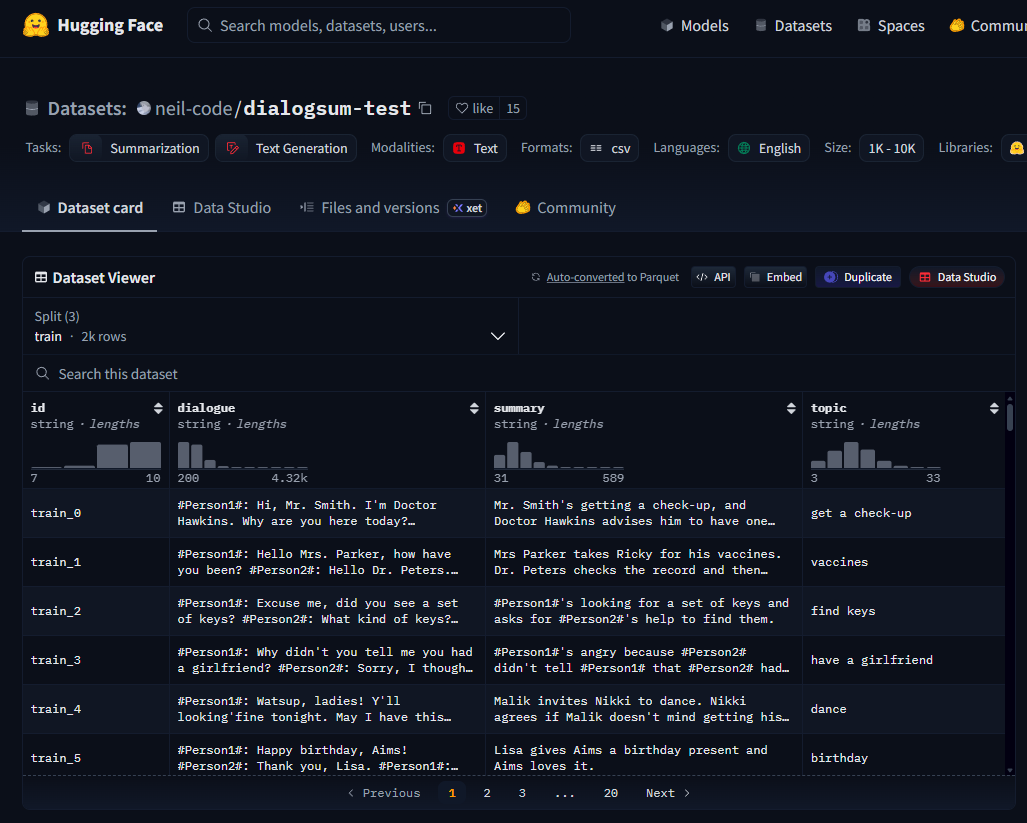

这玩意是一个大规模对话摘要数据集，包含 13,460 条对话（外加 100 条用于主题生成的保留数据），并配有相应的手动标记摘要和主题。

In [5]:
dataset_name = "neil-code/dialogsum-test"
dataset = load_dataset(dataset_name)

In [ ]:
dataset         

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
})

In [7]:
dataset['train'][0]

{'id': 'train_0',
 'dialogue': "#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. Why are you here today?\n#Person2#: I found it would be a good idea to get a check-up.\n#Person1#: Yes, well, you haven't had one for 5 years. You should have one every year.\n#Person2#: I know. I figure as long as there is nothing wrong, why go see the doctor?\n#Person1#: Well, the best way to avoid serious illnesses is to find out about them early. So try to come at least once a year for your own good.\n#Person2#: Ok.\n#Person1#: Let me see here. Your eyes and ears look fine. Take a deep breath, please. Do you smoke, Mr. Smith?\n#Person2#: Yes.\n#Person1#: Smoking is the leading cause of lung cancer and heart disease, you know. You really should quit.\n#Person2#: I've tried hundreds of times, but I just can't seem to kick the habit.\n#Person1#: Well, we have classes and some medications that might help. I'll give you more information before you leave.\n#Person2#: Ok, thanks doctor.",
 'summary': "Mr. Smith'

In [8]:
def create_prompt_formats(sample):
    """
   Format various fields of the sample ('instruction','output')
   :param sample: input data
   """
    INTRO_BLURB = "Instruct: Below is an instruction that describes a task. Write a response that appropriately completes the request."
    INSTRUCTION_KEY = "Input: Please Summarize the below conversation."
    RESPONSE_KEY = "Output:"
    
    blurb = f"\n{INTRO_BLURB}"
    instruction = f"{INSTRUCTION_KEY}"
    input_context = f"{sample['dialogue']}" if sample["dialogue"] else None
    response = f"{RESPONSE_KEY}\n{sample['summary']}"
    
    parts = [part for part in [blurb, instruction, input_context, response] if
part]
    formatted_prompt = "\n\n".join(parts)
    sample["text"] = formatted_prompt
    return sample

In [9]:
print(create_prompt_formats(dataset['train'][0])['text'])


Instruct: Below is an instruction that describes a task. Write a response that appropriately completes the request.

Input: Please Summarize the below conversation.

#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. Why are you here today?
#Person2#: I found it would be a good idea to get a check-up.
#Person1#: Yes, well, you haven't had one for 5 years. You should have one every year.
#Person2#: I know. I figure as long as there is nothing wrong, why go see the doctor?
#Person1#: Well, the best way to avoid serious illnesses is to find out about them early. So try to come at least once a year for your own good.
#Person2#: Ok.
#Person1#: Let me see here. Your eyes and ears look fine. Take a deep breath, please. Do you smoke, Mr. Smith?
#Person2#: Yes.
#Person1#: Smoking is the leading cause of lung cancer and heart disease, you know. You really should quit.
#Person2#: I've tried hundreds of times, but I just can't seem to kick the habit.
#Person1#: Well, we have classes and some medicatio

In [10]:
compute_dtype = getattr(torch, "float16")
quant_config = BitsAndBytesConfig(
 load_in_4bit=True,
 bnb_4bit_quant_type="nf4",
 bnb_4bit_compute_dtype=compute_dtype,
 bnb_4bit_use_double_quant=True,
)

In [11]:
model_path = "/root/autodl-tmp/LLM-Research/Meta-Llama-3-8B-Instruct/"
original_model = AutoModelForCausalLM.from_pretrained(
 model_path,
 torch_dtype=compute_dtype,
 device_map={"": 0},
 quantization_config=quant_config
)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False,
trust_remote_code=True,
padding_side="left",add_eos_token=True,add_bos_token=True)
tokenizer.pad_token_id = tokenizer.eos_token_id

In [13]:
eval_tokenizer = AutoTokenizer.from_pretrained(model_path, add_bos_token=True,
trust_remote_code=True, use_fast=False)
eval_tokenizer.pad_token = eval_tokenizer.eos_token
def gen(model,p, maxlen=100, sample=True):
    toks = eval_tokenizer(p, return_tensors="pt")
    res = model.generate(**toks.to("cuda"), max_new_tokens=maxlen,
do_sample=sample,num_return_sequences=1,temperature=0.1,num_beams=1,top_p=0.95,
).to('cpu')
    return eval_tokenizer.batch_decode(res,skip_special_tokens=True)

In [14]:
%%time
from transformers import set_seed
seed = 42
set_seed(seed)
index = 10
 
prompt = dataset['test'][index]['dialogue']
summary = dataset['test'][index]['summary']
formatted_prompt = f"Instruct: Summarize the following conversation.\nInput:{prompt}\nOutput:\n"
res = gen(original_model,formatted_prompt,100,)
#print(res[0])
output = res[0].split('Output:\n')[1]
dash_line = '-'.join('' for x in range(100))
print(dash_line)
print(f'INPUT PROMPT:\n{formatted_prompt}')
print(dash_line)
print(f'BASELINE HUMAN SUMMARY:\n{summary}\n')
print(dash_line)
print(f'MODEL GENERATION - ZERO SHOT:\n{output}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


---------------------------------------------------------------------------------------------------
INPUT PROMPT:
Instruct: Summarize the following conversation.
Input:#Person1#: Happy Birthday, this is for you, Brian.
#Person2#: I'm so happy you remember, please come in and enjoy the party. Everyone's here, I'm sure you have a good time.
#Person1#: Brian, may I have a pleasure to have a dance with you?
#Person2#: Ok.
#Person1#: This is really wonderful party.
#Person2#: Yes, you are always popular with everyone. and you look very pretty today.
#Person1#: Thanks, that's very kind of you to say. I hope my necklace goes with my dress, and they both make me look good I feel.
#Person2#: You look great, you are absolutely glowing.
#Person1#: Thanks, this is a fine party. We should have a drink together to celebrate your birthday
Output:

---------------------------------------------------------------------------------------------------
BASELINE HUMAN SUMMARY:
#Person1# attends Brian's birth

In [15]:
def get_max_length(model):
    conf = model.config
    max_length = None
    for length_setting in ["n_positions", "max_position_embeddings",
"seq_length"]:
        max_length = getattr(model.config, length_setting, None)
        if max_length:
            print(f"Found max lenth: {max_length}")
            break
        if not max_length:
            max_length = 1024
        print(f"Using default max length: {max_length}")
    return max_length
 
def preprocess_batch(batch, tokenizer, max_length):
    """
    Tokenizing a batch
    """
    return tokenizer(
        batch["text"],
        max_length=max_length,
        truncation=True,
    )


In [16]:
from functools import partial
def preprocess_dataset(tokenizer: AutoTokenizer, max_length: int,seed,
dataset):
    # Add prompt to each sample
    print("Preprocessing dataset...")
    dataset = dataset.map(create_prompt_formats)
    _preprocessing_function = partial(preprocess_batch, max_length=max_length,
tokenizer=tokenizer)
    dataset = dataset.map(
        _preprocessing_function,
        batched=True,
        remove_columns=['id', 'topic', 'dialogue', 'summary'],
   )
    # 过滤样本
    dataset = dataset.filter(lambda sample: len(sample["input_ids"]) <
max_length)
    # Shuffle 数据
    dataset = dataset.shuffle(seed=seed)
    print("Preprocessing dataset done.")
    return dataset


In [17]:
max_length = get_max_length(original_model)
print(max_length)
train_dataset = preprocess_dataset(tokenizer, max_length,seed,
dataset['train'])
eval_dataset = preprocess_dataset(tokenizer, max_length,seed,
dataset['validation'])

Using default max length: 1024
Found max lenth: 8192
8192
Preprocessing dataset...
Preprocessing dataset done.
Preprocessing dataset...


Map:   0%|          | 0/499 [00:00<?, ? examples/s]

Filter:   0%|          | 0/499 [00:00<?, ? examples/s]

Preprocessing dataset done.


In [18]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
config = LoraConfig(
    r=32, #Rank
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    lora_dropout=0.01, # Conventional
    task_type="CAUSAL_LM",
)
# 1 - Enabling gradient checkpointing to reduce memory usage during fine-tuning
original_model.gradient_checkpointing_enable()
# 2 - Using the prepare_model_for_kbit_training method from PEFT
original_model = prepare_model_for_kbit_training(original_model)
peft_model = get_peft_model(original_model, config)


In [20]:
output_dir = './peft-dialogue-summary-training/final-checkpoint'
import transformers
peft_training_args = TrainingArguments(
    output_dir = output_dir,
    warmup_steps=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    max_steps=2000,
    learning_rate=2e-4,
    optim="paged_adamw_8bit",
    logging_steps=100,
    logging_dir="./logs",
    save_strategy="steps",
    save_steps=100,
    eval_strategy="steps",
    eval_steps=100,
    do_eval=True,
    gradient_checkpointing=True,
    report_to="none",
    overwrite_output_dir = 'True',
    group_by_length=True,
)
peft_model.config.use_cache = False
peft_trainer = transformers.Trainer(
    model=peft_model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=peft_training_args,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer,
mlm=False),
)


In [21]:
peft_trainer.train()

Step,Training Loss,Validation Loss
100,1.457500,1.445629
200,1.355900,1.426464
300,1.356200,1.421379
400,1.343500,1.414138
500,1.354400,1.420983
600,1.274200,1.416433
700,1.292000,1.404479
800,1.295900,1.401834
900,1.353500,1.398416
1000,1.352600,1.395936


TrainOutput(global_step=2000, training_loss=1.333669589996338, metrics={'train_runtime': 1368.2333, 'train_samples_per_second': 1.462, 'train_steps_per_second': 1.462, 'total_flos': 2.366768522067149e+16, 'train_loss': 1.333669589996338, 'epoch': 1.0005002501250626})

In [22]:
def print_number_of_trainable_model_parameters(model):
    trainable_model_params = 0
    all_model_params = 0
    for _, param in model.named_parameters():
        all_model_params += param.numel()
        if param.requires_grad:
            trainable_model_params += param.numel()
    return f"trainable model parameters: {trainable_model_params}\n \
               all model parameters: {all_model_params}\n \
               percentage of trainable model parameters: \
               {100 * trainable_model_params / all_model_params:.2f}%"

In [23]:
print_number_of_trainable_model_parameters(original_model)


'trainable model parameters: 27262976\n                all model parameters: 4567863296\n                percentage of trainable model parameters:                0.60%'

In [24]:
del original_model
del peft_trainer
torch.cuda.empty_cache()

In [25]:
compute_dtype = getattr(torch, "float16")
 
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)
model_path = "/root/autodl-tmp/LLM-Research/Meta-Llama-3-8B-Instruct/"
base_model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=compute_dtype,
    device_map={"": 0},
    quantization_config=quant_config
)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [26]:
eval_tokenizer = AutoTokenizer.from_pretrained(model_path, add_bos_token=True,
trust_remote_code=True, use_fast=False)
eval_tokenizer.pad_token = eval_tokenizer.eos_token

In [27]:
from peft import PeftModel
ft_model = PeftModel.from_pretrained(
    base_model,
    "./peft-dialogue-summary-training/final-checkpoint/checkpoint-500",
    torch_dtype=torch.float16,
    is_trainable=False
)

In [28]:
!nvidia-smi

Thu Feb 26 16:00:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:39:00.0 Off |                  Off |
| 30%   33C    P2             54W /  450W |   15831MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [33]:
%%time
index = 10

prompt = dataset['test'][index]['dialogue']
summary = dataset['test'][index]['summary']
formatted_prompt = f"""Instruct: Summarize the following conversation.
Input:
{prompt}
Output:
"""
res = gen(ft_model, formatted_prompt, 100,)
# print(res[0])
output = res[0].split('Output:\n')[1]
dash_line = '-'.join('' for x in range(100))
print(dash_line)
print(f'INPUT PROMPT:\n{formatted_prompt}')
print(dash_line)
print(f'BASELINE HUMAN SUMMARY:\n{summary}\n')
print(dash_line)
print(f'PEFT MODEL GENERATION:\n{output}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


---------------------------------------------------------------------------------------------------
INPUT PROMPT:
Instruct: Summarize the following conversation.
Input:
#Person1#: Happy Birthday, this is for you, Brian.
#Person2#: I'm so happy you remember, please come in and enjoy the party. Everyone's here, I'm sure you have a good time.
#Person1#: Brian, may I have a pleasure to have a dance with you?
#Person2#: Ok.
#Person1#: This is really wonderful party.
#Person2#: Yes, you are always popular with everyone. and you look very pretty today.
#Person1#: Thanks, that's very kind of you to say. I hope my necklace goes with my dress, and they both make me look good I feel.
#Person2#: You look great, you are absolutely glowing.
#Person1#: Thanks, this is a fine party. We should have a drink together to celebrate your birthday
Output:

---------------------------------------------------------------------------------------------------
BASELINE HUMAN SUMMARY:
#Person1# attends Brian's birt